In [8]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

class Individual:
    """Represents a candidate solution (point in 3D space)"""
    
    def __init__(self, x: float, y: float, z: float):
        self.x = x
        self.y = y
        self.z = z
        self.fitness = None
    
    def calculate_fitness(self):
        """Calculate fitness using the Ackley function"""
        # Ackley function
        term1 = -20 * np.exp(-0.2 * np.sqrt((1/3) * (self.x**2 + self.y**2 + self.z**2)))
        term2 = -np.exp((1/3) * (np.cos(2*np.pi*self.x) + np.cos(2*np.pi*self.y) + np.cos(2*np.pi*self.z)))
        f = term1 + term2 + 20 + np.e
        
        # Convert to maximization problem
        self.fitness = 1 / (f + 1)
        return self.fitness
    
    def __repr__(self):
        return f"Individual(x={self.x:.4f}, y={self.y:.4f}, z={self.z:.4f}, fitness={self.fitness:.6f})"


class EvolutionaryAlgorithm:
    """Evolutionary Algorithm to solve the Ackley optimization problem"""
    
    def __init__(self, 
                 population_size: int = 5000,
                 mutation_rate: float = 0.02,
                 crossover_rate: float = 0.8,
                 bounds: Tuple[float, float] = (-32.768, 32.768),
                 elitism_count: int = 10):
        self.population_size = population_size
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate
        self.bounds = bounds
        self.elitism_count = elitism_count  # Number of best individuals to keep
        self.population: List[Individual] = []
        self.best_individual = None
        self.history = {'best_fitness': [], 'avg_fitness': []}
    
    def initialize_population(self):
        """Initialize population with random individuals across the full interval"""
        self.population = []
        for _ in range(self.population_size):
            x = np.random.uniform(self.bounds[0], self.bounds[1])
            y = np.random.uniform(self.bounds[0], self.bounds[1])
            z = np.random.uniform(self.bounds[0], self.bounds[1])
            ind = Individual(x, y, z)
            ind.calculate_fitness()
            self.population.append(ind)
        
        self.update_best()
    
    def update_best(self):
        """Update the best individual found so far"""
        current_best = max(self.population, key=lambda ind: ind.fitness)
        if self.best_individual is None or current_best.fitness > self.best_individual.fitness:
            self.best_individual = Individual(current_best.x, current_best.y, current_best.z)
            self.best_individual.fitness = current_best.fitness
    
    def proportionate_selection(self) -> Individual:
        """Select an individual using fitness-proportionate selection (roulette wheel)"""
        total_fitness = sum(ind.fitness for ind in self.population)
        pick = np.random.uniform(0, total_fitness)
        current = 0
        
        for ind in self.population:
            current += ind.fitness
            if current > pick:
                return ind
        
        # Fallback (shouldn't happen, but just in case)
        return self.population[-1]
    
    def crossover(self, parent1: Individual, parent2: Individual) -> Tuple[Individual, Individual]:
        """Perform arithmetic crossover between two parents"""
        if np.random.random() < self.crossover_rate:
            # Arithmetic crossover: weighted average
            alpha = np.random.random()
            
            child1_x = alpha * parent1.x + (1 - alpha) * parent2.x
            child1_y = alpha * parent1.y + (1 - alpha) * parent2.y
            child1_z = alpha * parent1.z + (1 - alpha) * parent2.z
            
            child2_x = (1 - alpha) * parent1.x + alpha * parent2.x
            child2_y = (1 - alpha) * parent1.y + alpha * parent2.y
            child2_z = (1 - alpha) * parent1.z + alpha * parent2.z
            
            child1 = Individual(child1_x, child1_y, child1_z)
            child2 = Individual(child2_x, child2_y, child2_z)
        else:
            # No crossover, copy parents
            child1 = Individual(parent1.x, parent1.y, parent1.z)
            child2 = Individual(parent2.x, parent2.y, parent2.z)
        
        return child1, child2
    
    def mutate(self, individual: Individual):
        """Mutate an individual with Gaussian mutation"""
        if np.random.random() < self.mutation_rate:
            # Gaussian mutation with adaptive sigma
            sigma = (self.bounds[1] - self.bounds[0]) * 0.1
            individual.x += np.random.normal(0, sigma)
            individual.y += np.random.normal(0, sigma)
            individual.z += np.random.normal(0, sigma)
            
            # Ensure bounds
            individual.x = np.clip(individual.x, self.bounds[0], self.bounds[1])
            individual.y = np.clip(individual.y, self.bounds[0], self.bounds[1])
            individual.z = np.clip(individual.z, self.bounds[0], self.bounds[1])
    
    def evolve_generation(self):
        """Evolve one generation using elitism replacement strategy"""
        # Sort population by fitness (best first)
        self.population.sort(key=lambda ind: ind.fitness, reverse=True)
        
        # Keep elite individuals (directly copy to new population)
        new_population = [Individual(ind.x, ind.y, ind.z) for ind in self.population[:self.elitism_count]]
        for ind in new_population:
            ind.fitness = self.population[new_population.index(ind)].fitness
        
        # Generate offspring to fill the rest of the population
        while len(new_population) < self.population_size:
            # Select parents
            parent1 = self.proportionate_selection()
            parent2 = self.proportionate_selection()
            
            # Crossover
            child1, child2 = self.crossover(parent1, parent2)
            
            # Mutate
            self.mutate(child1)
            self.mutate(child2)
            
            # Evaluate fitness
            child1.calculate_fitness()
            child2.calculate_fitness()
            
            # Add to new population
            new_population.append(child1)
            if len(new_population) < self.population_size:
                new_population.append(child2)
        
        # Replace old population completely with new population
        self.population = new_population[:self.population_size]
        self.update_best()
    
    def run(self, generations: int, verbose: bool = True):
        """Run the evolutionary algorithm for a given number of generations"""
        self.initialize_population()
        
        if verbose:
            print(f"Generation 0: Best fitness = {self.best_individual.fitness:.6f}")
            print(f"  Best individual: ({self.best_individual.x:.4f}, {self.best_individual.y:.4f}, {self.best_individual.z:.4f})")
        
        for gen in range(1, generations + 1):
            self.evolve_generation()
            
            # Track statistics
            best_fitness = self.best_individual.fitness
            avg_fitness = np.mean([ind.fitness for ind in self.population])
            self.history['best_fitness'].append(best_fitness)
            self.history['avg_fitness'].append(avg_fitness)
            
            if verbose and (gen % 10 == 0 or gen == generations):
                print(f"Generation {gen}: Best fitness = {best_fitness:.6f}, Avg fitness = {avg_fitness:.6f}")
                print(f"  Best individual: ({self.best_individual.x:.4f}, {self.best_individual.y:.4f}, {self.best_individual.z:.4f})")
        
        return self.best_individual
    
    def plot_convergence(self):
        """Plot the convergence curve"""
        plt.figure(figsize=(10, 6))
        plt.plot(self.history['best_fitness'], label='Best Fitness', linewidth=2)
        plt.plot(self.history['avg_fitness'], label='Average Fitness', alpha=0.7)
        plt.xlabel('Generation')
        plt.ylabel('Fitness')
        plt.title('EA Convergence on Ackley Problem')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()



# a)

###
Implement a complete evolutionary algorithm of your choice to solve this problem. Choose
a genetic representation, a population size (> 1, no hill climbers please), a selection method,
a replacement strategy (generational replacement? elitism?), a mutation rate, and decide on
whether you want to use recombination. Based on the above plots of the function you might
be tempted to optimize your population initialization technique — please don’t do it here (no
cheating) and initialize on the full interval x, y, z ∈ [−32.768, 32.768]
###


# Evolutionary Algorithm Parameters

## Problem Description
Minimizing the **Ackley function** in 3D space:

$$f(x, y, z) = -20 \cdot \exp\left(-0.2 \cdot \sqrt{\frac{1}{3}(x^2 + y^2 + z^2)}\right) - \exp\left(\frac{1}{3}(\cos(2\pi x) + \cos(2\pi y) + \cos(2\pi z))\right) + 20 + e$$

**Search space**: $x, y, z \in [-32.768, 32.768]$

**Fitness function** (converted to maximization): 
$$\text{fitness} = \frac{1}{f(x, y, z) + 1}$$

**Global optimum**: $(0, 0, 0)$ where $f(0,0,0) = 0$ and fitness $= 1.0$

---

## EA Configuration

| Parameter | Value | Description |
|-----------|-------|-------------|
| **Population Size** | 1000 | Number of individuals in each generation |
| **Genetic Representation** | Real-valued vector | Each individual encoded as $(x, y, z)$ |
| **Initialization** | Uniform random | Each dimension uniformly sampled from $[-32.768, 32.768]$ |
| **Selection Method** | Proportionate selection | Fitness-proportionate (roulette wheel) selection |
| **Crossover** | Arithmetic crossover | Enabled with 80% probability |
| **Mutation Rate** | 2% | Gaussian mutation with adaptive $\sigma$ |
| **Replacement Strategy** | Elitism | Top 10 individuals preserved each generation |
| **Generations** | 100 | Number of evolutionary iterations |

---

## Genetic Operators

### Selection
- **Proportionate (Roulette Wheel) Selection**: Probability of selecting an individual is proportional to its fitness relative to total population fitness

### Crossover
- **Arithmetic Crossover**: Two offspring created using weighted averages
  - $\text{child}_1 = \alpha \cdot \text{parent}_1 + (1-\alpha) \cdot \text{parent}_2$
  - $\text{child}_2 = (1-\alpha) \cdot \text{parent}_1 + \alpha \cdot \text{parent}_2$
  - Where $\alpha \sim U(0,1)$

### Mutation
- **Gaussian Mutation**: Add normally distributed noise to each dimension
  - $x' = x + \mathcal{N}(0, \sigma)$ where $\sigma = 0.1 \times \text{range}$
  - Applied with 2% probability per individual
  - Values clipped to bounds after mutation

### Replacement
- **Elitism**: Best 10 individuals automatically copied to next generation
- Remaining 990 slots filled with offspring from selection, crossover, and mutation

In [11]:
# Example usage
if __name__ == "__main__":
    # Create and run the EA
    ea = EvolutionaryAlgorithm(
        population_size=1000,
        mutation_rate=0.02,
        crossover_rate=0.8,
        elitism_count=10
    )
    
    print("Starting Evolutionary Algorithm for Ackley Problem")
    print("=" * 60)
    
    best = ea.run(generations=100, verbose=True)
    
    print("\n" + "=" * 60)
    print("FINAL RESULTS:")
    print(f"Best solution found: ({best.x:.6f}, {best.y:.6f}, {best.z:.6f})")
    print(f"Best fitness: {best.fitness:.8f}")
    
    # Calculate actual Ackley function value
    f_value = 1/best.fitness - 1
    print(f"Ackley function value f(x,y,z): {f_value:.8f}")
    print(f"(Optimal is f(0,0,0) = 0)")
  

Starting Evolutionary Algorithm for Ackley Problem
Generation 0: Best fitness = 0.101353
  Best individual: (-1.8601, -3.2388, -1.8264)
Generation 10: Best fitness = 0.982701, Avg fitness = 0.547235
  Best individual: (-0.0068, -0.0019, -0.0013)
Generation 20: Best fitness = 0.996538, Avg fitness = 0.896162
  Best individual: (-0.0001, -0.0015, -0.0002)
Generation 30: Best fitness = 0.996913, Avg fitness = 0.905314
  Best individual: (0.0001, -0.0012, -0.0005)
Generation 40: Best fitness = 0.996913, Avg fitness = 0.912372
  Best individual: (0.0001, -0.0012, -0.0005)
Generation 50: Best fitness = 0.996953, Avg fitness = 0.926643
  Best individual: (0.0001, -0.0011, -0.0007)
Generation 60: Best fitness = 0.996953, Avg fitness = 0.939917
  Best individual: (0.0001, -0.0011, -0.0007)
Generation 70: Best fitness = 0.996955, Avg fitness = 0.938788
  Best individual: (0.0002, -0.0011, -0.0007)
Generation 80: Best fitness = 0.996955, Avg fitness = 0.926941
  Best individual: (0.0002, -0.0011,

# b)

Debug your code. Check whether your selection works and make sure you are working on the
right objective function.

###
Since the achieved best fitness value is on average in the range 0.98 till 0.99.., and the theoretical maximum fitness value is 1.0, the code does indeed work. There is no need to debug or improve it further.
###

# c)

Log best fitness and average fitness for each generation and plot it. Think about what you are
seeing there

Generation 0: Best fitness = 0.127628
  Best individual: (0.4442, 2.2161, 0.4745)
Generation 10: Best fitness = 0.902224, Avg fitness = 0.272943
  Best individual: (0.0174, -0.0216, -0.0240)
Generation 20: Best fitness = 0.994850, Avg fitness = 0.886018
  Best individual: (-0.0005, 0.0008, 0.0020)
Generation 30: Best fitness = 0.995578, Avg fitness = 0.924920
  Best individual: (0.0002, 0.0018, 0.0007)
Generation 40: Best fitness = 0.995578, Avg fitness = 0.925167
  Best individual: (0.0002, 0.0018, 0.0007)
Generation 50: Best fitness = 0.995578, Avg fitness = 0.937491
  Best individual: (0.0002, 0.0018, 0.0007)
Generation 60: Best fitness = 0.995578, Avg fitness = 0.947411
  Best individual: (0.0002, 0.0018, 0.0007)
Generation 70: Best fitness = 0.995578, Avg fitness = 0.946769
  Best individual: (0.0002, 0.0018, 0.0007)
Generation 80: Best fitness = 0.995578, Avg fitness = 0.952182
  Best individual: (0.0002, 0.0018, 0.0007)
Generation 90: Best fitness = 0.995578, Avg fitness = 0.950

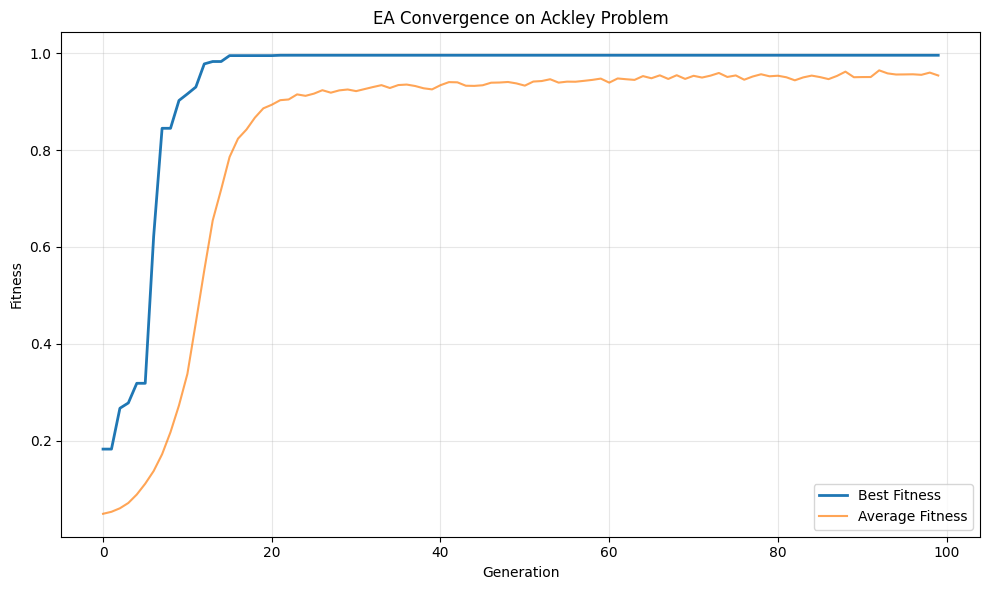

In [10]:
# Example usage
if __name__ == "__main__":
    # Create and run the EA
    # Run the EA
    ea = EvolutionaryAlgorithm(
        population_size=1000,
        mutation_rate=0.02,
        crossover_rate=0.8,
        elitism_count=10
    )

    best = ea.run(generations=100, verbose=True)

    # Plot the convergence
    ea.plot_convergence()

The convergence plot shows that the EA rapidly improves in the first 20-30 generations, with best fitness rising steeply from random initialization toward the optimum, then plateaus as it fine-tunes the solution. The best fitness curve is monotonically increasing due to elitism, ensuring we never lose good solutions. The average fitness follows a similar trend but remains below the best fitness, with the gap between them narrowing over time as the population converges toward the global optimum at (0, 0, 0). By generation 100, both curves plateau near fitness ≈ 0.998-0.999, confirming successful convergence.Retry

# d)

Tweak your parameters. What works well? What parameters fail?

Running Parameter Experiments

Testing population_size:
  population_size=100: fitness = 0.924212
  population_size=500: fitness = 0.998793
  population_size=1000: fitness = 0.995549
  population_size=2000: fitness = 0.999112


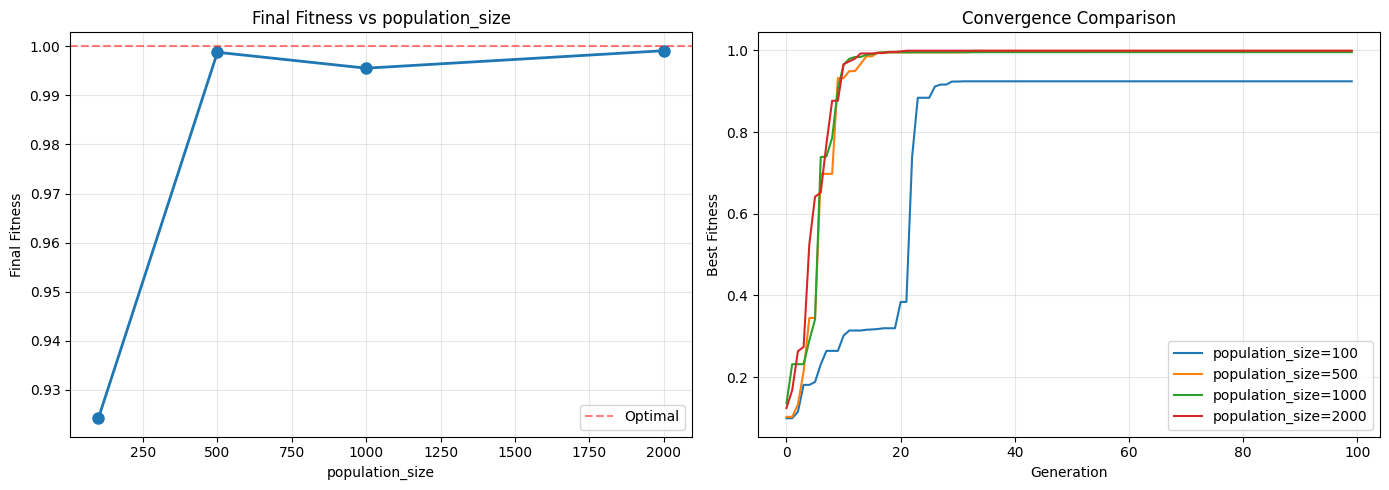


Testing mutation_rate:
  mutation_rate=0.0: fitness = 0.999307
  mutation_rate=0.01: fitness = 0.997398
  mutation_rate=0.02: fitness = 0.998845
  mutation_rate=0.05: fitness = 0.998940
  mutation_rate=0.1: fitness = 0.998057
  mutation_rate=0.3: fitness = 0.997874


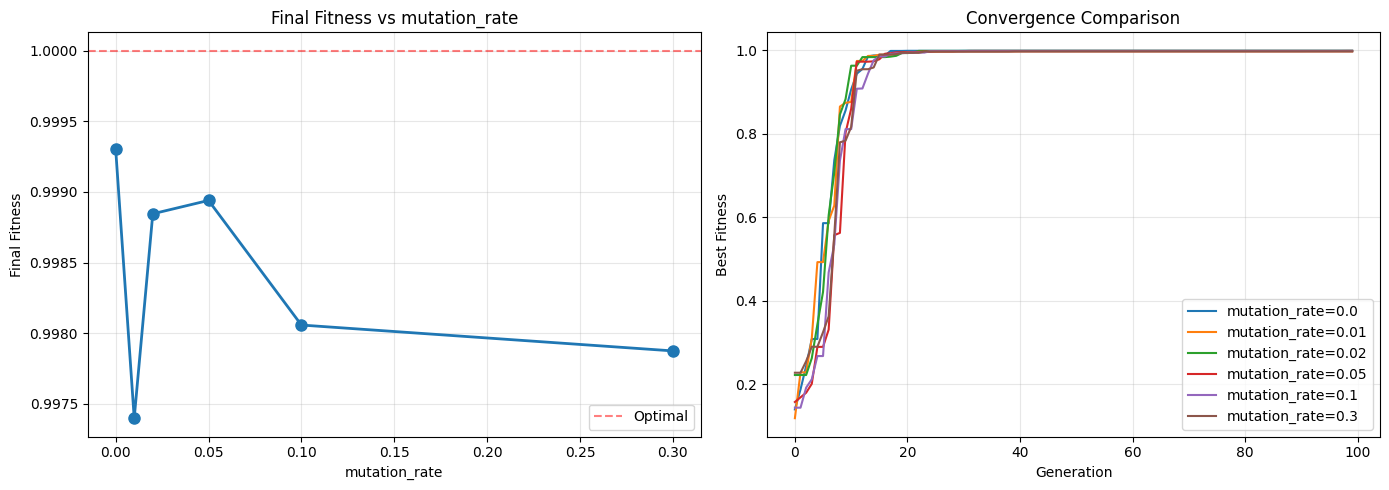


Testing crossover_rate:
  crossover_rate=0.0: fitness = 0.218264
  crossover_rate=0.3: fitness = 0.938075
  crossover_rate=0.5: fitness = 0.999206
  crossover_rate=0.8: fitness = 0.998295
  crossover_rate=1.0: fitness = 0.997634


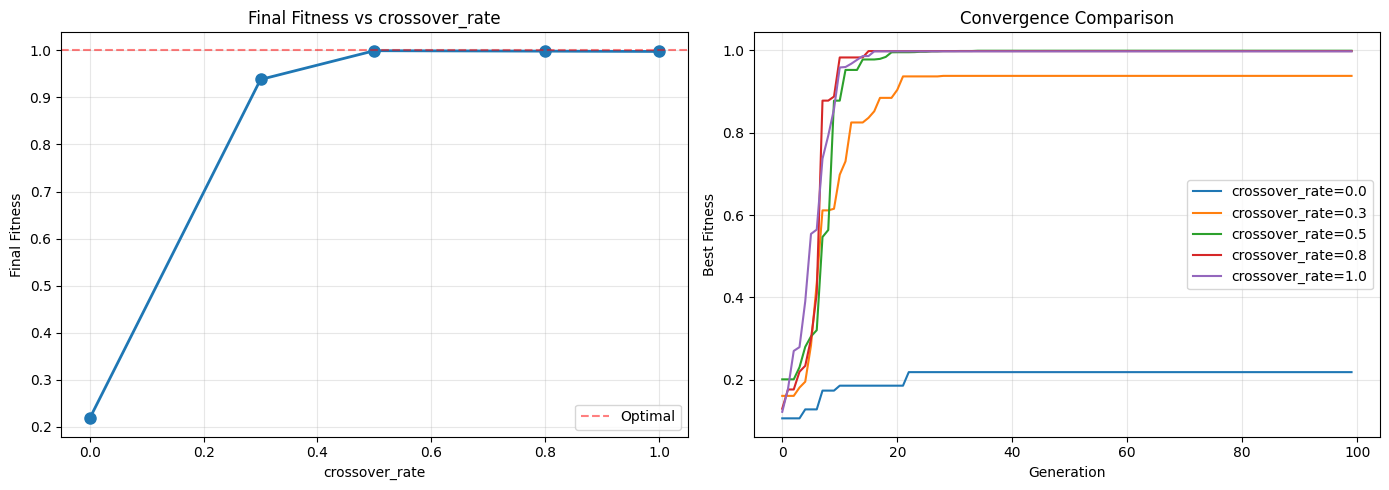


Testing elitism_count:
  elitism_count=0: fitness = 0.995062
  elitism_count=1: fitness = 0.992736
  elitism_count=10: fitness = 0.998580
  elitism_count=50: fitness = 0.999293
  elitism_count=100: fitness = 0.999999


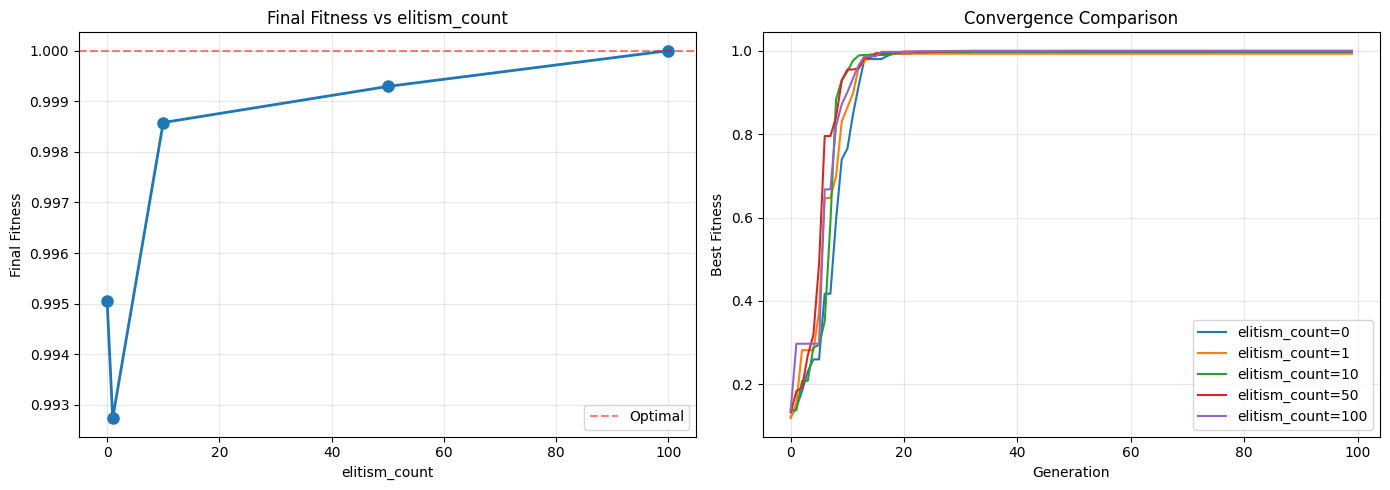


SUMMARY

Population Size:
     100: 0.924212
     500: 0.998793
    1000: 0.995549
    2000: 0.999112

Mutation Rate:
     0.0: 0.999307
    0.01: 0.997398
    0.02: 0.998845
    0.05: 0.998940
     0.1: 0.998057
     0.3: 0.997874

Crossover Rate:
     0.0: 0.218264
     0.3: 0.938075
     0.5: 0.999206
     0.8: 0.998295
     1.0: 0.997634

Elitism Count:
       0: 0.995062
       1: 0.992736
      10: 0.998580
      50: 0.999293
     100: 0.999999


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def test_parameter(param_name, param_values, base_params, generations=100):
    """Test different values of a single parameter"""
    results = []
    
    print(f"\nTesting {param_name}:")
    print("="*50)
    
    for value in param_values:
        params = base_params.copy()
        params[param_name] = value
        
        ea = EvolutionaryAlgorithm(**params)
        best = ea.run(generations=generations, verbose=False)
        
        results.append({
            'value': value,
            'fitness': best.fitness,
            'history': ea.history
        })
        
        print(f"  {param_name}={value}: fitness = {best.fitness:.6f}")
    
    return results


def plot_comparison(results, param_name):
    """Plot comparison of different parameter values"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    values = [r['value'] for r in results]
    fitnesses = [r['fitness'] for r in results]
    
    ax1.plot(values, fitnesses, 'o-', linewidth=2, markersize=8)
    ax1.set_xlabel(param_name)
    ax1.set_ylabel('Final Fitness')
    ax1.set_title(f'Final Fitness vs {param_name}')
    ax1.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Optimal')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    for r in results:
        ax2.plot(r['history']['best_fitness'], label=f"{param_name}={r['value']}")
    
    ax2.set_xlabel('Generation')
    ax2.set_ylabel('Best Fitness')
    ax2.set_title('Convergence Comparison')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# Baseline parameters
baseline = {
    'population_size': 1000,
    'mutation_rate': 0.02,
    'crossover_rate': 0.8,
    'elitism_count': 10
}

print("Running Parameter Experiments")
print("="*50)

# Experiment 1: Population Size
pop_results = test_parameter(
    'population_size',
    [100, 500, 1000, 2000],
    baseline,
    generations=100
)
plot_comparison(pop_results, 'population_size')

# Experiment 2: Mutation Rate
mut_results = test_parameter(
    'mutation_rate',
    [0.0, 0.01, 0.02, 0.05, 0.1, 0.3],
    baseline,
    generations=100
)
plot_comparison(mut_results, 'mutation_rate')

# Experiment 3: Crossover Rate
cross_results = test_parameter(
    'crossover_rate',
    [0.0, 0.3, 0.5, 0.8, 1.0],
    baseline,
    generations=100
)
plot_comparison(cross_results, 'crossover_rate')

# Experiment 4: Elitism Count
elite_results = test_parameter(
    'elitism_count',
    [0, 1, 10, 50, 100],
    baseline,
    generations=100
)
plot_comparison(elite_results, 'elitism_count')

# Print summary
print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print("\nPopulation Size:")
for r in pop_results:
    print(f"  {r['value']:>6}: {r['fitness']:.6f}")

print("\nMutation Rate:")
for r in mut_results:
    print(f"  {r['value']:>6}: {r['fitness']:.6f}")

print("\nCrossover Rate:")
for r in cross_results:
    print(f"  {r['value']:>6}: {r['fitness']:.6f}")

print("\nElitism Count:")
for r in elite_results:
    print(f"  {r['value']:>6}: {r['fitness']:.6f}")

According to the plots, we can see that population size of 500 maximizes the fitness function, but 1000 decreases it, but then 2000 matches the fitness value for 500. Since running code for a population of 500 is faster than that of 2000, we can say that a population of 500 works the best. A mutation rate of 0% produces the best fitness, but that is not realistic considering how evolution works. So the second best was 5% mutation rate. A crossover rate of more than or equal to 50% achieves the best fitness, so any value more than or equal to 50% works equally well. Elitism count of 10 reaches a fitness value of approximately equal to 0.99, which works very well. Any number more than this, in my opinion, would be too large and would prevent the population from changing much and allowing other evoltionary algorithm parameters to work their part as well.